In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import tree

In [11]:
df = pd.read_csv('drugs (1).csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [13]:
feature_cols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
X = df[feature_cols].values
y = df['Drug']

In [27]:
Cod_BP = preprocessing.LabelEncoder()
Cod_BP.fit(['LOW','NORMAL','HIGH'])
X[:,2] = Cod_BP.transform(X[:,2])

Cod_Chol = preprocessing.LabelEncoder()
Cod_Chol.fit(['NORMAL', 'HIGH'])
X[:,3] = Cod_Chol.transform(X[:,3])

In [29]:
X[0:5]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 1)

In [33]:
criterios = ['gini', 'entropy']
profundidades = [2, 3, 4, 5, 6]

for c in criterios:
    for d in profundidades:
        print('===', c, 'depth=', d, '===')
        clf = DecisionTreeClassifier(criterion=c, max_depth=d)
        clf = clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        print('Acurracy:', metrics.accuracy_score(y_test, y_pred))
        print(classification_report(y_test, y_pred))
        print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

=== gini depth= 2 ===
Acurracy: 0.8333333333333334
              precision    recall  f1-score   support

       drugA       0.40      1.00      0.57         4
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.45      0.60      0.50        60
weighted avg       0.74      0.83      0.77        60

Confusion matrix:
 [[ 4  0  0  0  0]
 [ 6  0  0  0  0]
 [ 0  0  0  4  0]
 [ 0  0  0 19  0]
 [ 0  0  0  0 27]]
=== gini depth= 3 ===
Acurracy: 0.9
              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       1.00      1.00      1.00

Con depth=2 y 3 el modelo no aprende bien drugB y sobre todo drugC (recall/precision en 0), aunque la accuracy suba. Con depth=4 ya logra ~0.97 de accuracy y casi todo queda perfecto; el único error constante es que 2 de 6 casos de drugB se predicen como drugA. Gini y Entropy dan lo mismo, así que la mejor opción es depth=4 (por buen rendimiento sin hacer el árbol más complejo).

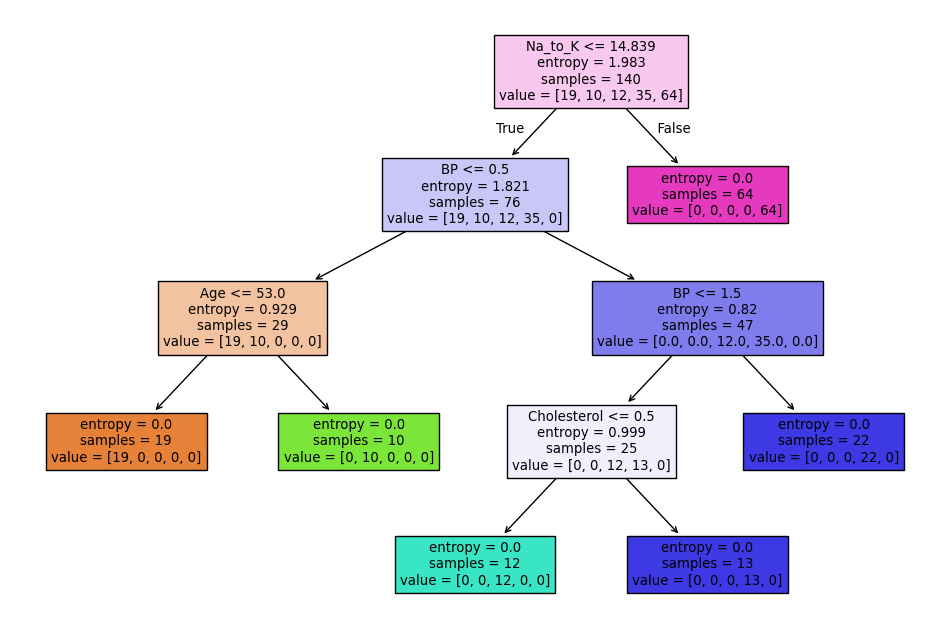

In [35]:
plt.figure(figsize=(12,8))
tree.plot_tree(clf, feature_names=feature_cols, filled=True)
plt.show()

En el árbol se ve que Na_to_K es el factor más determinante: cuando está por encima del umbral, el modelo clasifica casi siempre como drugY (nodo muy puro). Cuando Na_to_K es bajo, la predicción ya depende de BP y se afina con edad y colesterol, separando principalmente entre drugA/drugB y drugX/drugC. En general, el modelo logra hojas con alta pureza, con la principal confusión ocurriendo entre drugB y drugA.

In [37]:
nuevo = [[50, 'F', 'HIGH', 'NORMAL', 15.302]]

nuevo[0][1] = Cod_Sex.transform([nuevo[0][1]])[0]
nuevo[0][2] = Cod_BP.transform([nuevo[0][2]])[0]
nuevo[0][3] = Cod_Chol.transform([nuevo[0][3]])[0]

pred = clf.predict(nuevo)
pred

array(['drugY'], dtype=object)